
# How to use this workbook — Quick run guide ✅

1. Set `directory`, `w`, and `x` to point to the desired session and recording. Run the imports and the session-selection cells.
2. Run the Data Loading cell to load `differential_emg`, `adc1`, timestamps, and `MessageCenter` messages. Inspect the full-trace plot to ensure channels and signal quality.
3. Tune `pre_event_time`, `post_event_time`, `stim_threshold`, `offstim_threshold`, and the M/H windows if necessary.
4. Run the stim detection loop to extract peri-stim windows, then run the MessageCenter parsing and grouping cells.
5. Run the matching/averaging cell to compute group averages and detect M/H peaks, then run the aggregation/normalization cells to generate recruitment curves.
6. For reproducible analyses or batch processing, consider refactoring detection, grouping, and plotting into functions or integrating into `emg_characterization_stage`.

💡 Tip: If you see missed triggers or false detections, first check `stim_threshold` and the search window around sync timestamps; then inspect a few raw peri-stim windows to select conservative thresholds.

# Set up Imports and Libraries

In [174]:
# === Import Necessary Libraries ===
# These are core scientific Python tools for data analysis and visualization.
# === Import Necessary Libraries ===
# These are core scientific Python tools for data analysis and visualization.
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import ipywidgets as widgets
from open_ephys.analysis import Session
from scipy.signal import butter, filtfilt, lfilter
import json
from pathlib import Path
from collections import defaultdict
import scipy.stats as stats
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from helpers import *

# Override default protocol for this notebook
DEFAULT_PROTOCOL = PROTOCOL_OFFLINE


# 1. Selecting and Exploring a Recording Session

Open Ephys organizes experiments into “sessions,” each with one or more Record Nodes.
Here we select which node to analyze and define which session directory to load.



### Function: Scanning Experiment Structure

We’ll define a helper function to automatically list all experiments and recordings inside a session directory.

In [175]:
def scan_experiment_structure(session_dir, record_node_name="Record Node 106"):
    """
    Scans a given Open Ephys session directory and returns a dictionary of 
    experiment names and their associated recordings.
    """
    node_path = os.path.join(session_dir, record_node_name)
    
    if not os.path.exists(node_path):
        print(f"Record Node directory not found: {node_path}")
        return {}
    
    experiment_info = defaultdict(list)
    for item in sorted(os.listdir(node_path)):
        exp_path = os.path.join(node_path, item)
        if os.path.isdir(exp_path) and item.startswith("experiment"):
            recordings = [r for r in sorted(os.listdir(exp_path)) 
                          if os.path.isdir(os.path.join(exp_path, r)) and r.startswith("recording")]
            experiment_info[item] = recordings
    return experiment_info


# 2. Loading the Session Data

Now let’s point Python to a specific Open Ephys session directory and create a Session object.

In [218]:
# ==== Load Session ====

#directory = '1-21-2026/HRPilot-06_Test1_2026-01-21_10-53-20_001'
#directory = '1-21-2026/HRPilot-06_Test2_2026-01-21_19-59-58_003'
#directory = '1-21-2026/HRPilot-08_Test1_2026-01-21_11-48-40_002'
#directory = '1-21-2026/HRPilot-08_Test2_2026-01-21_20-22-57_004'
#directory = '1-21-2026/HRPilot-09_Test12026-01-21_18-17-01_001'
#directory = '1-21-2026/HRPilot-10_Test1_2026-01-21_17-30-13_001'
#directory = '1-21-2026/HRPilot-10_Test2_2026-01-21_18-38-25_002'

directory = '2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002'
#directory = '2-17-2026/SEQ-3-1mm_Electrode_Placement__Test2_2026-02-17_14-42-32_003'
#directory = '2-17-2026/SEQ-3-5mm_Electrode_Placement__Test1_2026-02-17_15-56-31_004'

session = Session(directory)
print('✅ Pass Initial Test, Moving on to Loading Session...\n')

✅ Pass Initial Test, Moving on to Loading Session...



### Scanning the Session's Structure

In [219]:
record_node_name = "Record Node 106" if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else "Record Node 111"
record_node_index = 0 if DEFAULT_PROTOCOL == PROTOCOL_ONLINE else 1
structure = scan_experiment_structure(directory, record_node_name)

# Flatten all experiment-recording pairs
flat_recordings = []
for exp_name, rec_list in structure.items():
    for rec in rec_list:
        flat_recordings.append((exp_name, rec))

print(f"Found {len(flat_recordings)} recordings across {len(structure)} experiments.")

Found 1 recordings across 1 experiments.


# Data loading and trace overview

This cell loads the continuous stream and metadata for the selected recording and prepares the primary signals used by the rest of the notebook:

- `differential_emg`: main EMG trace used for M/H detection (default channel index 3).
- `adc1`: absolute ADC channel used to detect stimulation pulses (default channel index 4).
- `timestamps`, `sample_rate`, `channel_names`: recording metadata used to convert between samples and time.

Notes & tips:
- If channel indices differ in your recording, update the channel indices above before running the detection pipeline.
- The `MessageCenter` files (`text.npy`, `timestamps.npy`) are loaded here and supply stim settings and trigger messages used for grouping.
- Full-trace plotting provides a quick visual check of signal quality and large artifacts (helpful to tune thresholds).

In [ ]:

# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# Make options from flat_recordings if available
try:
    rec_options = [f"{i}: {e}/{r}" for i,(e,r) in enumerate(flat_recordings)]
except Exception:
    rec_options = []

recording_dropdown = Dropdown(options=rec_options, description='Recording:')
load_recording_button = Button(description='Open Recording', button_style='primary')
rec_output = Output()


def on_open_recording(b):
    with rec_output:
        clear_output()
        if not recording_dropdown.options:
            print("No recordings discovered. Use the 'Load Session' button in Phase 0 and select a record node.")
            return
        sel = recording_dropdown.value
        idx = int(str(sel).split(':',1)[0])
        try:
            # Try to fetch recording from Session object
            recording = session.recordnodes[record_node_index].recordings[idx]
            globals()['recording'] = recording
            print("Loaded recording:", recording)
            directory_str = recording.directory
            globals()['directory_str'] = directory_str

            parts = directory_str.split(os.sep)
            record_node_name = parts[-3]
            experiment_name  = parts[-2]
            recording_name   = parts[-1]
            globals()['record_node_name'] = record_node_name
            globals()['experiment_name'] = experiment_name
            globals()['recording_name'] = recording_name

            # Extract continuous data and metadata
            stream = recording.continuous[0]
            metadata = stream.metadata
            globals()['sample_rate'] = metadata.sample_rate
            globals()['num_channels'] = metadata.num_channels
            globals()['channel_names'] = metadata.channel_names

            print(f"Sample rate: {metadata.sample_rate} Hz | Channels: {metadata.num_channels} | Names: {metadata.channel_names}")

            # Update BIN_SAMPLE_COUNT based on actual sample_rate
            global BIN_SAMPLE_COUNT
            BIN_SAMPLE_COUNT = int((metadata.sample_rate / 1000) * BIN_DURATION_MS)
            print(f"BIN_SAMPLE_COUNT set to {BIN_SAMPLE_COUNT} samples")

            # Preload full data (be careful on large datasets)
            timestamps = stream.timestamps
            n_timestamps = timestamps.shape[0]
            data = stream.get_samples(start_sample_index=0, end_sample_index=n_timestamps)
            globals()['timestamps'] = timestamps
            globals()['data'] = data
            print("Data shape:", data.shape)

        except Exception as e:
            print("Error loading recording:", e)

load_recording_button.on_click(on_open_recording)

display(recording_dropdown, load_recording_button, rec_output)


Dropdown(description='Recording:', options=('0: experiment1/recording1',), value='0: experiment1/recording1')

Button(button_style='primary', description='Open Recording', style=ButtonStyle())

Output()

In [221]:

# Phase 1: Load MessageCenter events using helpers
try:
    message_entries = load_message_center_events(
        directory_str, record_node_name, experiment_name, recording_name)
    for t, txt in message_entries[:20]:
        print(f"[Time: {t:.6f} s] Message: {txt}")
except Exception as e:
    print("MessageCenter load error:", e)
    message_entries = []

Loaded 653 MessageCenter entries from 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002\Record Node 111\experiment1\recording1\events\MessageCenter
[Time: 63.287000 s] Message: Electrode placement experiment for 1mm, all 5 placed in.
[Time: 78.582800 s] Message: Filtered node, is each channel unipolar filtered
[Time: 89.557600 s] Message: Starting at 0.05 mA
[Time: 92.119800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 96.135000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 100.111800 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 104.127000 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 108.142200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 112.119200 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 116.134400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 120.111400 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 124.126600 s] Message: RHDCONTROL TRIGGER 1 500.0
[Time: 124.470600 s] Message: Starting at 0.10 mA
[Time: 128.141600 s] Message: RHDCONTROL TRIGGER 1 500.0


C:\Users\dal866445\AppData\Local\Temp\ipykernel_30412\868459133.py:79: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


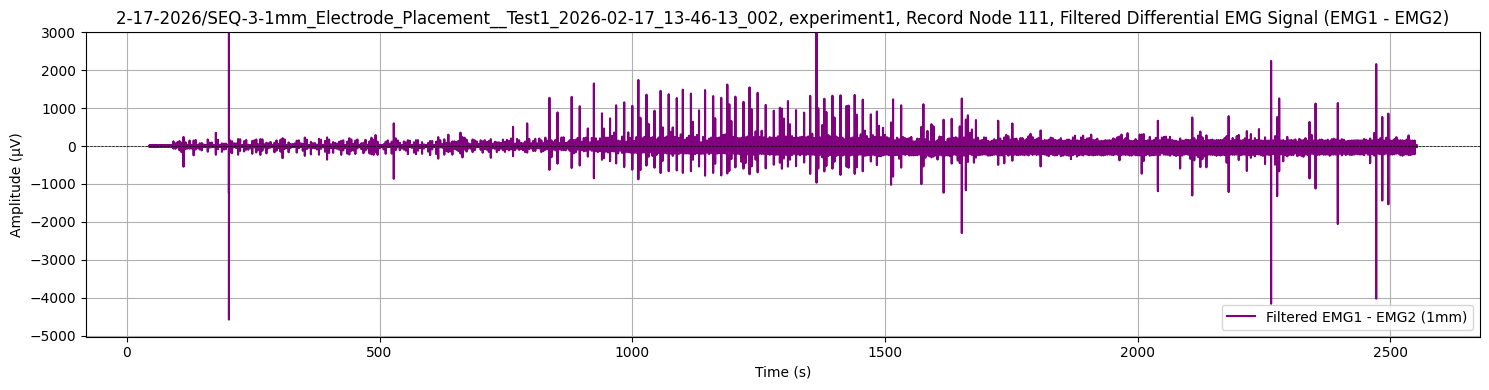

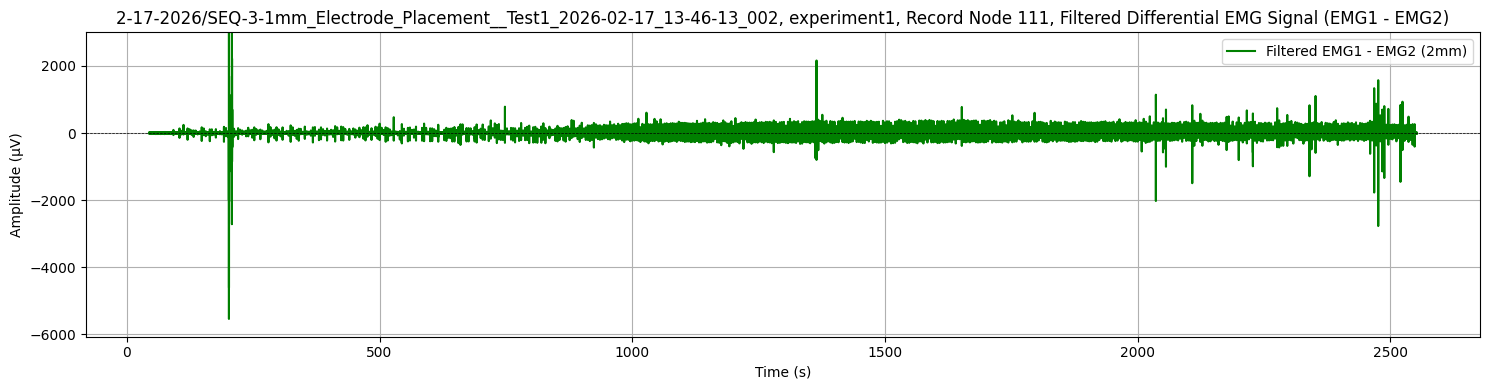

C:\Users\dal866445\AppData\Local\Temp\ipykernel_30412\868459133.py:105: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


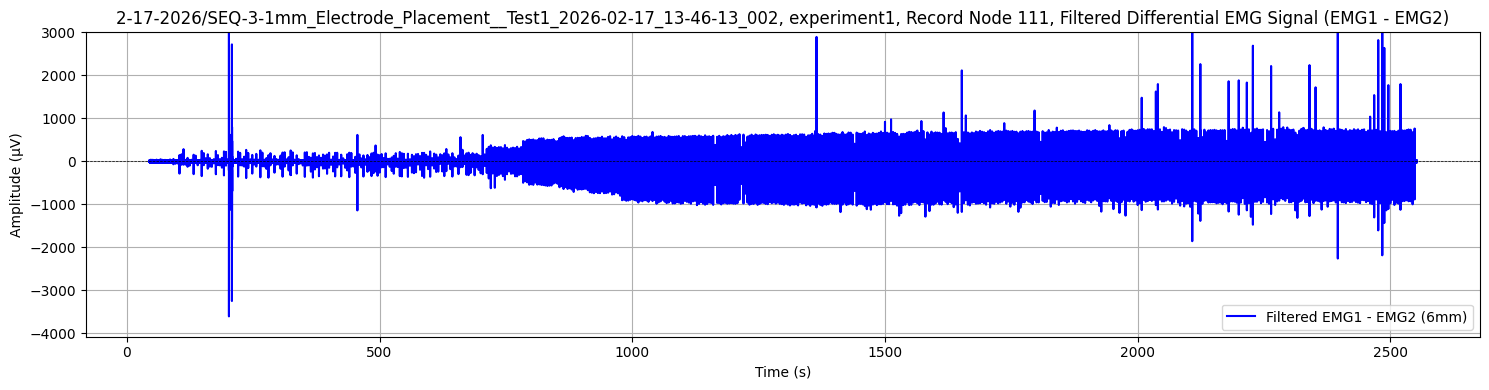

C:\Users\dal866445\AppData\Local\Temp\ipykernel_30412\868459133.py:118: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


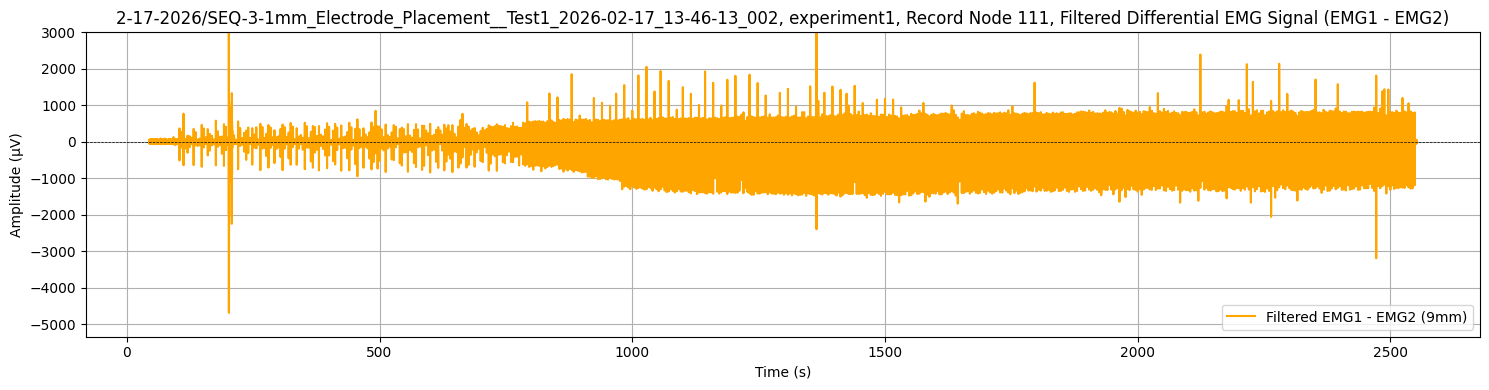

In [222]:



# Phase 1: Recording selection and metadata loading
from ipywidgets import Button, Output, Dropdown

# ==== EMG Processing (Pull Channel 11 Index 4)====


'''
 Channels: 7 | Names: ['CH1', 'CH5', 'CH7', 'CH8', 'CH10', 'CH12', 'ADC1']
'''



# ==== EMG Processing ====
emg5_raw = data[:, 1] # Ch5
emg7_raw = data[:, 2] # Ch7
emg8_raw = data[:, 3] # Ch8
emg10_raw = data[:, 4] # Ch10
emg12_raw = data[:, 5] # Ch12


# ==== EMG Processing ====
#emg1_raw = data[:, 2]
#emg2_raw = data[:, 3]


differential_1mm = (emg7_raw - emg5_raw)
differential_2mm = (emg12_raw - emg10_raw)
differential_6mm = (emg10_raw - emg7_raw)
differential_9mm = (emg12_raw - emg5_raw)

## ==== Set bandpass filter parameters ====
lowcut = 100
highcut = 1000

b, a = butter(2, np.array([lowcut, highcut])/(sample_rate/2), btype='bandpass')


# ==== Filter the differential signals ====


differential_1mm_filt = lfilter(b, a, differential_1mm)
differential_1mm_abs = np.abs(differential_1mm_filt)
differential_1mm_emg = differential_1mm_filt

differential_2mm_filt = lfilter(b, a, differential_2mm)
differential_2mm_abs = np.abs(differential_2mm_filt)
differential_2mm_emg = differential_2mm_filt

differential_6mm_filt = lfilter(b, a, differential_6mm)
differential_6mm_abs = np.abs(differential_6mm_filt)
differential_6mm_emg = differential_6mm_filt

differential_9mm_filt = lfilter(b, a, differential_9mm)
differential_9mm_abs = np.abs(differential_9mm_filt)
differential_9mm_emg = differential_9mm_filt


# ==== Load ADC1 (for stim detection) ====
adc1 = np.abs(data[:, 4])  # adjust if your ADC1 channel index differs


# ==== Shared y-axis limits across all 4 channels for easy comparison ====
'''shared_ylim = autoscale_ylim(
    differential_1mm_emg, differential_2mm_emg,
    differential_6mm_emg, differential_9mm_emg
)'''

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_1mm_emg, label="Filtered EMG1 - EMG2 (1mm)", color='purple')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {experiment_name}, {record_node_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
#plt.ylim(shared_ylim)
plt.ylim(top=3000)
plt.tight_layout()
plt.show()

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_2mm_emg, label="Filtered EMG1 - EMG2 (2mm)", color='green')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {experiment_name}, {record_node_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=3000)
plt.tight_layout()
plt.show()

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_6mm_emg, label="Filtered EMG1 - EMG2 (6mm)", color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {experiment_name}, {record_node_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=3000)
plt.tight_layout()
plt.show()

# ==== Full Trace Plot ====
plt.figure(figsize=(15, 4))
plt.plot(timestamps, differential_9mm_emg, label="Filtered EMG1 - EMG2 (9mm)", color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.title(f"{directory}, {experiment_name}, {record_node_name}, Filtered Differential EMG Signal (EMG1 - EMG2)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (μV)")
plt.grid(True)
plt.legend()
plt.ylim(top=3000)
plt.tight_layout()
plt.show()


# Peri‑stimulus extraction parameters

These parameters define the peri‑stimulus windows and thresholds used by the stim detection routine:

- `pre_event_time` (ms): time before the detected stim start to include in the window.
- `post_event_time` (ms): time after the detected stim start to include.
- `stim_threshold` (ADC units): threshold used to detect stim onset in `adc1`.
- `offstim_threshold` (ADC units): threshold to detect stim end after the onset.
- `m_wave_start` / `m_wave_end`, `h_wave_start` / `h_wave_end` (ms): expected M- and H-wave windows used for peak detection.

Adjust these values if the stimulation artifact or EMG timing differs from these defaults.

In [223]:
# ==== Peri-Stimulus Analysis with Shaded Stimulus Duration ====
pre_event_time = 5   # ms before calculated stim start
post_event_time = 20 # ms after calculated stim start
stim_threshold = 0.01 # ADC1 threshold to detect pulse (adjust if needed)
offstim_threshold = .41


m_wave_start, m_wave_end = 1.5, 4.5
h_wave_start, h_wave_end = 4.6, 10


peri_stim_segments = []
peri_stim_segments_adc1 = []
segment_stim_end_times = []
segment_stim_start_times = []

# ==== Sync Setup ====
print(f"\n{experiment_name}, {recording_name}")
print(recording)


# ==== Sync Events ====
events = recording.events
sync_events = events[(events.line == 1) & (events.processor_id == 100) &
                        (events.stream_name == 'Rhythm Data') & (events.state == 1)]
sync_timestamps = sync_events['timestamp'].to_numpy()





experiment1, recording1
Open Ephys GUI Recording
ID: 0x2b1ed2eff50
Format: Binary
Directory: 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0


# Detecting stim starts from sync pulses + ADC1

This cell implements the core detection strategy:

1. Around each recorded sync timestamp we search a short time window in `adc1` for the first threshold crossing (`stim_threshold`) which is treated as the stim onset.
2. The peri-stimulus window is extracted using `pre_event_time` and `post_event_time` and zeroed relative to the stim onset.
3. The stim end is detected as the first time after onset where `adc1` falls below `offstim_threshold` (converted to ms). If not found, defaults to `post_event_time`.
4. Extracted windows are appended to `peri_stim_segments` and `peri_stim_segments_adc1` for later grouping and averaging.

Run this cell after verifying `pre_event_time`, `post_event_time`, and thresholds are appropriate for your recordings.

In [224]:
for stamp in sync_timestamps:
        # First, find approximate sample index around the sync pulse
        #idx_start = np.searchsorted(timestamps, stamp)
        #idx_end   = np.searchsorted(timestamps, stamp + 0.010)
        #idx_center = (idx_start + idx_end)/2

        idx_search_start = np.searchsorted(timestamps, stamp - 0.00003)  # 10 ms before sync
        idx_search_end   = np.searchsorted(timestamps, stamp + 0.010)  # 10 ms after sync

        if idx_search_start < 0 or idx_search_end > len(timestamps):
            continue

        adc1_segment_for_detection = adc1[idx_search_start:idx_search_end]
        time_segment_for_detection = timestamps[idx_search_start:idx_search_end]

        # Detect true stim start: first crossing above threshold in that window
        above_idxs = np.where(adc1_segment_for_detection > stim_threshold)[0]
        
        if len(above_idxs) == 0:
            continue
        stim_start_idx = idx_search_start + above_idxs[0]
        stim_start_time = timestamps[stim_start_idx]

        # Now define peri-stimulus window around this stim_start_time
        idx_pre  = int(stim_start_idx - (pre_event_time / 1000) * sample_rate)
        idx_post = int(stim_start_idx + (post_event_time / 1000) * sample_rate)

        if idx_pre < 0 or idx_post > len(timestamps):
            continue

        # Extract windows
        time_window = timestamps[idx_pre:idx_post]
        time_zeroed = time_window - stim_start_time  # in seconds

        emg_window  = differential_1mm_emg[idx_pre:idx_post]
        adc1_window = adc1[idx_pre:idx_post]

        # Detect stim end: first time after stim_start where ADC1 falls back below threshold
        post_onset_mask = (time_zeroed >= 0)
        adc1_post_onset = adc1_window[post_onset_mask]
        time_post_onset = time_zeroed[post_onset_mask]

        below_idxs = np.where(adc1_post_onset < offstim_threshold)[0]
        if len(below_idxs) > 0:
            stim_end_time = time_post_onset[below_idxs[0]] * 1000  # convert to ms
        else:
            stim_end_time = post_event_time

        # Save for grouping
        peri_stim_segments.append((time_zeroed * 1000, emg_window, stim_end_time))
        peri_stim_segments_adc1.append(adc1_window)
        segment_stim_start_times.append(stim_start_time)
        segment_stim_end_times.append(stim_end_time)

'''print(time_window)
print(idx_search_start)
print(idx_search_end)
print(peri_stim_segments_adc1)
print(peri_stim_segments)
print(stim_end_time)
type(stim_end_time)
'''


'print(time_window)\nprint(idx_search_start)\nprint(idx_search_end)\nprint(peri_stim_segments_adc1)\nprint(peri_stim_segments)\nprint(stim_end_time)\ntype(stim_end_time)\n'

# Parse MessageCenter and build stimulation groups

We extract stimulation configuration messages and triggers from `MessageCenter` to group triggers by stimulation amplitude:

- `stim_pattern` matches strings like "starting 0.5 mA" to begin a new group.
- `RHDCONTROL TRIGGER` entries are appended to the current amplitude group.
- Final result `stim_groups` is a list of `(amplitude, [trigger_times])`, ready for matching to peri-stimulus segments.

This grouping enables averaging across repeated stimuli at the same current setting.

In [225]:
# ==== Dynamically determine stimulation groups based on event messages ====

# First, extract only trigger messages and stim setting messages
trigger_pattern = re.compile(r"RHDCONTROL TRIGGER")
stim_pattern = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups = []
current_group = []
current_amp = None
trigger_times = []

for t, msg in message_entries:
    if stim_pattern.search(msg):
        # Save the previous group if any
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        # Start new group
        current_amp = float(stim_pattern.search(msg).group(1))
        current_group = []
    elif trigger_pattern.search(msg):
        if current_amp is not None:
            current_group.append(t)

# Don't forget to save the last group
if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))


# Assign groups and initialize peak arrays

This small cell initializes container lists used in the next loop where we average and plot per‑group responses. `stim_intensities`, `m_wave_peaks`, and `h_wave_peaks` are appended during the loop to store peak amplitudes per group.

# Match trigger times to peri‑stimulus segments

For each stimulation amplitude group we find peri‑stim windows that best match the trigger timestamps (closest `segment_stim_start_times`). This step:

- Builds `group_data`, `group_adc1`, `group_start_times` and `group_end_times` for each amplitude.
- Stacks windows into `time_ms_matrix` and `emg_matrix` so we can compute `avg_emg`, `avg_adc1`, and `avg_end_ms`.
- Detects M- and H-wave peaks within their specified windows and records peak times and amplitudes for later aggregation.

If a trigger has no reasonably close peri‑stim window it is skipped (helps avoid false matches).

In [226]:
# ==== Match trigger times to peri_stim_segments ====
# Create dictionary to associate each stim amplitude to its segments
stim_intensities = []
m_wave_peaks = []
h_wave_peaks = []

# Plotting & peak detection per stimulation group — notes

This loop does the following for each stimulation intensity group:

- Matches triggers to peri-stimulus segments and stacks them for averaging.
- Plots individual traces (faint) and the group average (bold black line).
- Shades the stimulus duration and the M/H windows.
- Finds M-wave and H-wave peaks (largest amplitude inside the respective windows) and annotates them on the plot.

Output:
- Figures per stimulation intensity showing individual traces, average trace, peak markers, and shaded regions for interpretation.

In [227]:
# Phase 3: Peri-stimulus viewer (2x2 paged, zoomable, saveable)
from ipywidgets import Button, Output, HBox, VBox, Dropdown, Label

# ==== Parameters ====
pre_event_time    = 5     # ms before stim onset to include in window
post_event_time   = 20    # ms after stim onset to include in window
stim_threshold    = 0.01  # ADC1 threshold to detect pulse onset (V)
offstim_threshold = 0.41  # ADC1 threshold to detect pulse end (V)

m_wave_start, m_wave_end = 1.5, 4.0
h_wave_start, h_wave_end = 4.5, 10.0

# ==== Channel definitions (label, signal, color) ====
# Channels: ['CH1','CH5','CH7','CH8','CH10','CH12','ADC1']  →  ADC1 is index 6
CHANNELS = [
    ('1mm', differential_1mm_emg, 'purple'),
    ('2mm', differential_2mm_emg, 'green'),
    ('6mm', differential_6mm_emg, 'blue'),
    ('9mm', differential_9mm_emg, 'orange'),
]
adc1_det = np.abs(data[:, 6])  # ADC1 for stim onset detection

# ==== Sync event detection ====
events = recording.events
sync_events = events[
    (events.line == 1) & (events.processor_id == 100) &
    (events.stream_name == 'Rhythm Data') & (events.state == 1)
]
sync_timestamps = sync_events['timestamp'].to_numpy()
print(f"Found {len(sync_timestamps)} sync events from {recording}")

# ==== Peri-stimulus extraction ====
# Each segment: (time_ms_array, {label: window_array}, stim_end_ms)
peri_stim_segments    = []
peri_stim_start_times = []

for stamp in sync_timestamps:
    i0 = np.searchsorted(timestamps, stamp - 0.00003)
    i1 = np.searchsorted(timestamps, stamp + 0.010)
    if i0 < 0 or i1 > len(timestamps):
        continue

    above = np.where(adc1_det[i0:i1] > stim_threshold)[0]
    if len(above) == 0:
        continue

    stim_idx  = i0 + above[0]
    stim_time = timestamps[stim_idx]

    idx_pre  = int(stim_idx - (pre_event_time  / 1000) * sample_rate)
    idx_post = int(stim_idx + (post_event_time / 1000) * sample_rate)
    if idx_pre < 0 or idx_post > len(timestamps):
        continue

    t_zeroed = timestamps[idx_pre:idx_post] - stim_time   # seconds

    # Detect stim end via ADC1 falling below offstim_threshold
    adc1_win   = adc1_det[idx_pre:idx_post]
    post_mask  = t_zeroed >= 0
    below      = np.where(adc1_win[post_mask] < offstim_threshold)[0]
    stim_end_ms = float(t_zeroed[post_mask][below[0]] * 1000) if len(below) > 0 else float(post_event_time)

    ch_windows = {label: sig[idx_pre:idx_post] for label, sig, _ in CHANNELS}

    peri_stim_segments.append((t_zeroed * 1000, ch_windows, stim_end_ms))
    peri_stim_start_times.append(stim_time)

print(f"Extracted {len(peri_stim_segments)} peri-stimulus segments")

# ==== Parse MessageCenter for stimulation amplitude groups ====
trig_re = re.compile(r"RHDCONTROL TRIGGER")
amp_re  = re.compile(r"starting(?: at)? (\d+\.?\d*)\s*mA", re.IGNORECASE)

stim_groups   = []
current_group = []
current_amp   = None

for t, msg in message_entries:
    if amp_re.search(msg):
        if current_amp is not None and current_group:
            stim_groups.append((current_amp, current_group))
        current_amp   = float(amp_re.search(msg).group(1))
        current_group = []
    elif trig_re.search(msg) and current_amp is not None:
        current_group.append(t)

if current_amp is not None and current_group:
    stim_groups.append((current_amp, current_group))

print(f"Found {len(stim_groups)} stimulation amplitude groups")

# ==== Merge groups with the same amplitude (avoids duplicate subplots) ====
_merged = {}
for _amp, _trigs in stim_groups:
    if _amp in _merged:
        _merged[_amp].extend(_trigs)
    else:
        _merged[_amp] = list(_trigs)
stim_groups = sorted(_merged.items())
print(f"After merging duplicates: {len(stim_groups)} unique amplitudes")

# ==== Build averaged groups ====
seg_arr          = np.array(peri_stim_start_times)
stim_intensities = []
m_wave_peaks     = []
h_wave_peaks     = []
groups_list      = []

for stim_amp, trig_times in stim_groups:
    ch_acc      = {label: [] for label, _, _ in CHANNELS}
    time_ms_ref = None
    end_ms_acc  = []

    used_in_group = set()
    for trig_time in trig_times:
        if len(seg_arr) == 0:
            continue
        idx_m = np.argmin(np.abs(seg_arr - trig_time))
        if abs(seg_arr[idx_m] - trig_time) >= 0.1:   # skip if >100 ms apart
            continue
        if idx_m in used_in_group:   # skip already-matched segment
            continue
        used_in_group.add(idx_m)
        t_ms, ch_wins, stim_end = peri_stim_segments[idx_m]
        if time_ms_ref is None:
            time_ms_ref = t_ms
        end_ms_acc.append(stim_end)
        for label, _, _ in CHANNELS:
            ch_acc[label].append(ch_wins[label])

    if time_ms_ref is None:
        continue

    ch_avgs  = {}
    n_trials = 0
    for label, _, _ in CHANNELS:
        ws = ch_acc[label]
        if ws:
            min_len = min(len(w) for w in ws)
            ch_avgs[label] = np.mean([w[:min_len] for w in ws], axis=0)
            n_trials = max(n_trials, len(ws))
        else:
            ch_avgs[label] = None

    valid_lens = [len(v) for v in ch_avgs.values() if v is not None]
    if not valid_lens:
        continue
    min_len = min(valid_lens)
    t_ms    = time_ms_ref[:min_len]
    ch_avgs = {k: (v[:min_len] if v is not None else None) for k, v in ch_avgs.items()}
    avg_end = float(np.mean(end_ms_acc)) if end_ms_acc else 0.0

    # Peak detection on 1mm channel → feeds downstream recruitment-curve cells
    ref = ch_avgs.get('1mm')
    if ref is not None:
        stim_intensities.append(stim_amp)
        m_mask = (t_ms >= m_wave_start) & (t_ms <= m_wave_end)
        h_mask = (t_ms >= h_wave_start) & (t_ms <= h_wave_end)
        m_wave_peaks.append(float(ref[m_mask].max()) if np.any(m_mask) else 0.0)
        h_wave_peaks.append(float(ref[h_mask].max()) if np.any(h_mask) else 0.0)

    groups_list.append({'amp': stim_amp, 'time_ms': t_ms, 'ch_avgs': ch_avgs,
                        'avg_end': avg_end, 'n_trials': n_trials})

# ==== Interactive paged viewer ====
if not groups_list:
    print('No valid stimulation groups found. Check peri_stim_segments and MessageCenter parsing.')
else:
    n_per_page = 4
    pages        = [groups_list[i:i + n_per_page] for i in range(0, len(groups_list), n_per_page)]
    current_page = {'idx': 0}
    print(f'Prepared {len(groups_list)} groups across {len(pages)} pages.')

    out         = Output()
    amp_dd      = Dropdown(options=[], description='View:')
    zoom_btn    = Button(description='View', button_style='info')
    active_conn = {'cid': None, 'canvas': None}

    def _draw(ax, g, fontsize=8):
        """Draw 4 colored avg traces + shaded regions onto ax."""
        t = g['time_ms']
        for label, _, color in CHANNELS:
            avg = g['ch_avgs'].get(label)
            if avg is not None:
                ax.plot(t, avg, color=color, linewidth=1.5, label=label)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
        ax.axvspan(0, g['avg_end'],          color='red',        alpha=0.20)
        ax.axvspan(m_wave_start, m_wave_end, color='lightblue',  alpha=0.30)
        ax.axvspan(h_wave_start, h_wave_end, color='lightgreen', alpha=0.30)
        ax.set_xlabel('(ms)', fontsize =20)
        ax.set_ylabel('(μV)', fontsize =20)
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.xaxis.set_minor_locator(MultipleLocator(0.5))
        ax.grid(True, which='both', alpha=0.3)
        try:
            ax.set_xlim(np.min(t), np.max(t))
        except Exception:
            pass
        ax.legend(fontsize=fontsize, loc='upper right', framealpha=0.8)

    def show_zoom(group):
        with out:
            out.clear_output(wait=True)
            fig, ax = plt.subplots(1, 1, figsize=(9, 5))
            _draw(ax, group, fontsize=9)
            ax.set_title(f"Stim Amp: {group['amp']:.2f} mA | n={group['n_trials']}", fontsize=11)
            plt.tight_layout()
            plt.show()

            back_btn = Button(description='Back to grid', button_style='info')
            save_btn = Button(description='Save PNG',     button_style='success')
            def on_back(b): plot_page(current_page['idx'])
            back_btn.on_click(on_back)
            def on_save(b):
                try:
                    fname = f"{globals().get('recording_name','rec')}_zoom_{group['amp']:.2f}mA.png"
                    fig.savefig(os.path.join(globals().get('directory_str', os.getcwd()), fname), dpi=150)
                    print(f'Saved: {fname}')
                except Exception as e:
                    print('Could not save PNG:', e)
            save_btn.on_click(on_save)
            display(HBox([back_btn, save_btn]))

    def plot_page(page_idx):
        try:
            if active_conn['cid'] is not None and active_conn['canvas'] is not None:
                active_conn['canvas'].mpl_disconnect(active_conn['cid'])
                active_conn['cid'] = None
                active_conn['canvas'] = None
        except Exception:
            pass
        with out:
            out.clear_output(wait=True)
            page = pages[page_idx]
            n    = len(page)
            fig, axs = plt.subplots(2, 2, figsize=(13, 8))
            axs = axs.flatten()

            amp_dd.options = [(f"{g['amp']:.2f} mA", idx) for idx, g in enumerate(page)]
            if amp_dd.options:
                amp_dd.value = 0

            for j in range(4):
                if j < n:
                    _draw(axs[j], page[j], fontsize=7)
                    axs[j].set_title(f"Stim Amp: {page[j]['amp']:.2f} mA | n={page[j]['n_trials']}", fontsize=20)
                else:
                    axs[j].axis('off')
            plt.tight_layout()
            plt.show()

            try:
                def on_click(event):
                    if event.inaxes is None:
                        return
                    for k, ax in enumerate(axs):
                        if event.inaxes == ax and k < n:
                            if getattr(event, 'dblclick', False):
                                show_zoom(page[k])
                            else:
                                amp_dd.value = k
                            break
                cid = fig.canvas.mpl_connect('button_press_event', on_click)
                active_conn['cid'] = cid
                active_conn['canvas'] = fig.canvas
            except Exception:
                pass

    def on_next(b):
        if current_page['idx'] < len(pages) - 1:
            current_page['idx'] += 1
            plot_page(current_page['idx'])

    def on_prev(b):
        if current_page['idx'] > 0:
            current_page['idx'] -= 1
            plot_page(current_page['idx'])

    def on_dd_change(change):
        if 'new' in change:
            current_page['idx'] = change['new']
            plot_page(current_page['idx'])

    def on_zoom(b):
        try:
            page = pages[current_page['idx']]
            if 0 <= int(amp_dd.value) < len(page):
                show_zoom(page[int(amp_dd.value)])
        except Exception:
            print('Could not zoom selected group.')

    next_btn = Button(description='Next',     button_style='primary')
    prev_btn = Button(description='Previous')
    page_dd  = Dropdown(options=[(f'Page {i+1}', i) for i in range(len(pages))], description='Page:')

    next_btn.on_click(on_next)
    prev_btn.on_click(on_prev)
    page_dd.observe(on_dd_change, names="value")
    zoom_btn.on_click(on_zoom)

    display(VBox([HBox([prev_btn, next_btn, page_dd, Label(' '), amp_dd, zoom_btn]), out]))
    plot_page(0)


Found 615 sync events from Open Ephys GUI Recording
ID: 0x2b1ed2eff50
Format: Binary
Directory: 2-17-2026/SEQ-3-1mm_Electrode_Placement__Test1_2026-02-17_13-46-13_002\Record Node 111\experiment1\recording1
Experiment Index: 0
Recording Index: 0
Extracted 615 peri-stimulus segments
Found 35 stimulation amplitude groups
After merging duplicates: 35 unique amplitudes
Prepared 35 groups across 9 pages.


In [228]:
#avg_emg  = np.mean(group_emg, axis=0)
#avg_adc1 = np.mean(group_adc1, axis=0)
#avg_end_time = np.mean(segment_stim_end_times)
#print(trace)
#print(time_ms)
#print(avg_adc1)
#print(avg_emg)
print(stim_end_time)
#print(segment_stim_start_times)
#print(group_emg)

20


# Aggregate peaks and normalize recruitment curves

This section aggregates M- and H-wave peak amplitudes across repetitions for each stimulation intensity, computes mean ± SEM, and normalizes M to M_max (100%).

Key outputs:
- `m_means`, `h_means`: mean peak amplitudes per intensity.
- `m_means_norm`, `h_means_norm`: amplitudes expressed as % of M_max.
- `current_at_50_percent`: current corresponding to 50% M_max (interpolation), used to normalize the x-axis.

Plots produced:
- Normalized recruitment curves (M and H) vs. normalized current.
- Box and whisker style plot of raw amplitudes across intensities.

Interpretation tips:
- `H_max` shows the maximum H response relative to Mmax; comparing H and M curves helps identify recruitment dynamics.

C:\Users\dal866445\AppData\Local\Temp\ipykernel_30412\1089052924.py:18: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
C:\Users\dal866445\AppData\Local\Temp\ipykernel_30412\1089052924.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])


NameError: name 'exp' is not defined

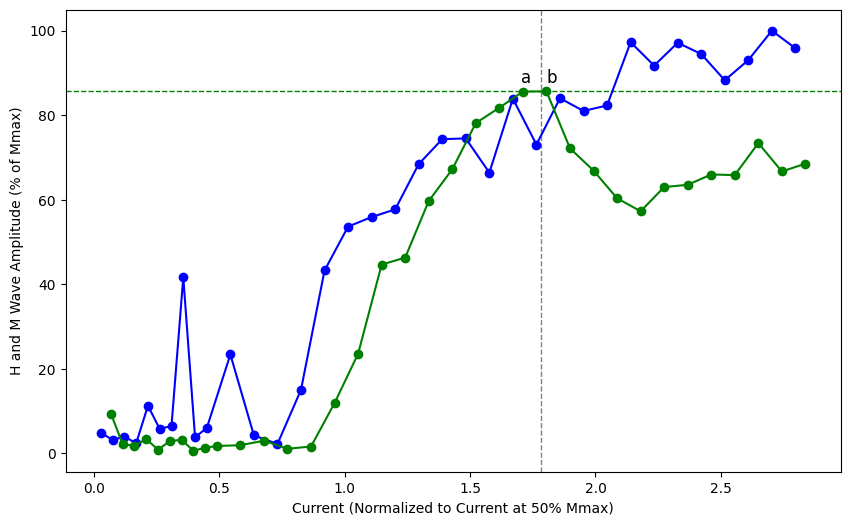

In [229]:
# ==== Group and Normalize Peak Amplitudes ====
m_wave_dict = defaultdict(list)
h_wave_dict = defaultdict(list)

# Ensure all amplitudes are absolute values
for amp, m_peak, h_peak in zip(stim_intensities, m_wave_peaks, h_wave_peaks):
    m_wave_dict[amp].append(abs(m_peak))
    h_wave_dict[amp].append(abs(h_peak))

# Sort stimulation intensities
sorted_amps = sorted(set(stim_intensities))
m_wave_data = [m_wave_dict[amp] for amp in sorted_amps]
h_wave_data = [h_wave_dict[amp] for amp in sorted_amps]

# Compute means
m_means = np.array([np.mean(peaks) for peaks in m_wave_data])
h_means = np.array([np.mean(peaks) for peaks in h_wave_data])
m_sems  = np.array([stats.sem(peaks) for peaks in m_wave_data])
h_sems  = np.array([stats.sem(peaks) for peaks in h_wave_data])

# Find M_max and normalize amplitudes
M_max = np.max(m_means)
m_means_norm = (m_means / M_max) * 100
h_means_norm = (h_means / M_max) * 100
m_sems_norm  = (m_sems  / M_max) * 100
h_sems_norm  = (h_sems  / M_max) * 100

# Interpolate M-curve to find current at 50% M_max
from scipy.interpolate import interp1d

interp_func = interp1d(m_means_norm, sorted_amps, kind='linear', bounds_error=False, fill_value='extrapolate')
try:
    current_at_50_percent = float(interp_func(50))
except:
    current_at_50_percent = sorted_amps[np.argmax(m_means_norm >= 50)]

# Normalize current axis
normalized_currents = np.array(sorted_amps) / current_at_50_percent

# Mark H_max (point "a") and Current at H_max (point "b")
H_max = np.max(h_means_norm)
idx_Hmax = np.argmax(h_means_norm)
current_at_Hmax_norm = normalized_currents[idx_Hmax]

# ==== Plot Normalized Recruitment Curves ====
fig, ax = plt.subplots(figsize=(10, 6))

# Overlay normalized mean ± SEM
ax.errorbar(normalized_currents - 0.02, m_means_norm, yerr=m_sems_norm, fmt='o-', color='blue', label='M-Wave (% Mmax)')
ax.errorbar(normalized_currents + 0.02, h_means_norm, yerr=h_sems_norm, fmt='o-', color='green', label='H-Wave (% Mmax)')

# Add point "a" (H_max) and "b" (Current at H_max)
ax.axhline(H_max, color='green', linestyle='--', linewidth=1, label=f'H_max = {H_max:.1f}% Mmax')
ax.axvline(current_at_Hmax_norm, color='gray', linestyle='--', linewidth=1, label=f'Current at H_max = {current_at_Hmax_norm:.2f}x')

# Add labels
ax.text(current_at_Hmax_norm + 0.02, H_max + 2, 'b', fontsize=12, color='black')
ax.text(normalized_currents[idx_Hmax] - 0.08, H_max + 2, 'a', fontsize=12, color='black')

# Aesthetics
#ax.set_xticks(np.round(normalized_currents, 2))
#ax.set_xticklabels([f"{x:.2f}" for x in normalized_currents])
ax.set_xlabel("Current (Normalized to Current at 50% Mmax)")
ax.set_ylabel("H and M Wave Amplitude (% of Mmax)")
ax.set_title(f"{exp}, {yy}, Normalized Recruitment Curves")
ax.grid(True)
ax.legend()
# Set window size here
ax.set_xlim(right=2)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()



# ==== Plot Recruitment Curves as Box-and-Whisker ====
fig, ax = plt.subplots(figsize=(10, 6))



# Boxplots
positions = np.arange(len(sorted_amps))  # for spacing

#Overlay mean ± SEM
ax.errorbar(positions - 0.2, m_means, yerr=m_sems, fmt='o-', color='blue', label='M-Wave Mean ± SEM')
ax.errorbar(positions + 0.2, h_means, yerr=h_sems, fmt='o-', color='green', label='H-Wave Mean ± SEM')

# Aesthetics
ax.set_xticks(positions)
tick_labels = []
for i, amp in enumerate(sorted_amps):
    if i % 10 == 0:  # show every 10th label
        tick_labels.append(f"{amp:.1f}")
    else:
        tick_labels.append("")  # leave blank

ax.set_xticklabels(tick_labels)

#ax.set_xticklabels([f"{amp:.1f}" for amp in sorted_amps])
ax.set_xlabel("Stimulation Intensity (mA)")
ax.set_ylabel("Peak Amplitude (μV)")
ax.set_title(f"{exp}, {yy}, Recruitment Curves")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

